In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
base_path = '/content/drive/MyDrive/dataset'

In [ ]:
random.seed(42)

output_path = '/content/dataset_effnet'
classes = ['organic', 'recyclable']

if os.path.exists(output_path):
    shutil.rmtree(output_path)

for cls in classes:
    class_path = os.path.join(base_path, cls)
    img_list = [f for f in os.listdir(class_path)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]

    random.shuffle(img_list)
    split_index = int(len(img_list) * 0.8)

    train_imgs = img_list[:split_index]
    test_imgs = img_list[split_index:]

    for folder in ['train','test']:
        os.makedirs(os.path.join(output_path, folder, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path,'train',cls,img))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path,'test',cls,img))

print("Split selesai!")

Split selesai!


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset_effnet/train',
    target_size=(224,224),
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    '/content/dataset_effnet/test',
    target_size=(224,224),
    class_mode='binary',
    shuffle=False
)

Found 19764 images belonging to 2 classes.
Found 4941 images belonging to 2 classes.


In [ ]:
base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)

Epoch 1/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2212s 4s/step - accuracy: 0.5583 - loss: 0.6889 - val_accuracy: 0.5618 - val_loss: 0.6877
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2130s 3s/step - accuracy: 0.5618 - loss: 0.6867 - val_accuracy: 0.5618 - val_loss: 0.6861
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2124s 3s/step - accuracy: 0.5618 - loss: 0.6857 - val_accuracy: 0.5618 - val_loss: 0.6857
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2129s 3s/step - accuracy: 0.5618 - loss: 0.6857 - val_accuracy: 0.5618 - val_loss: 0.6855
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2114s 3s/step - accuracy: 0.5618 - loss: 0.6855 - val_accuracy: 0.5618 - val_loss: 0.6855
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2109s 3s/step - accuracy: 0.5618 - loss: 0.6856 - val_accuracy: 0.5618 - val_loss: 0.6855
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2124s 3s/step - accuracy: 0.5618 - loss: 0.6855 - val_accuracy: 0.5618 - val_loss: 0.6855
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 2131s 3s/step - accuracy: 0.5618 - loss: 0.6855 - 

In [ ]:
print("TRAIN ACC:", history.history['accuracy'][-1])
print("TEST ACC :", history.history['val_accuracy'][-1])

TRAIN ACC: 0.5618295669555664
TEST ACC : 0.5618295669555664


In [ ]:
# TEST
test_gen.reset()
pred_test = model.predict(test_gen)
y_pred_test = (pred_test > 0.5).astype(int).reshape(-1)
y_true_test = test_gen.classes

# TRAIN
train_gen.reset()
pred_train = model.predict(train_gen)
y_pred_train = (pred_train > 0.5).astype(int).reshape(-1)
y_true_train = train_gen.classes

155/155 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step
618/618 ━━━━━━━━━━━━━━━━━━━━ 1779s 3s/step


In [ ]:
print("\n===== TESTING REPORT =====")
print(classification_report(y_true_test, y_pred_test, target_names=['organic','recyclable']))

print("\n===== TRAINING REPORT =====")
print(classification_report(y_true_train, y_pred_train, target_names=['organic','recyclable']))



===== TESTING REPORT =====
              precision    recall  f1-score   support

     organic       0.56      1.00      0.72      2776
  recyclable       0.00      0.00      0.00      2165

    accuracy                           0.56      4941
   macro avg       0.28      0.50      0.36      4941
weighted avg       0.32      0.56      0.40      4941


===== TRAINING REPORT =====
              precision    recall  f1-score   support

     organic       0.56      1.00      0.72     11104
  recyclable       0.00      0.00      0.00      8660

    accuracy                           0.56     19764
   macro avg       0.28      0.50      0.36     19764
weighted avg       0.32      0.56      0.40     19764



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Confusion Matrix:
 [[2776    0]
 [2165    0]]


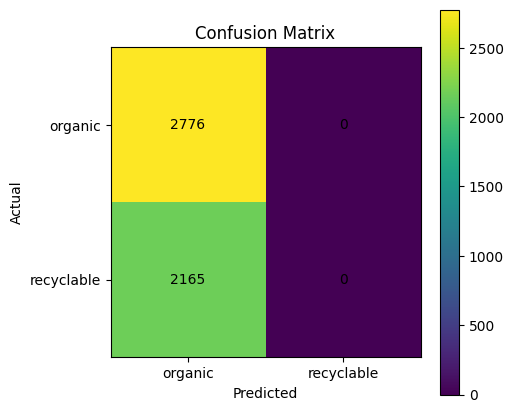

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['organic','recyclable']
plt.xticks(range(2), classes)
plt.yticks(range(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

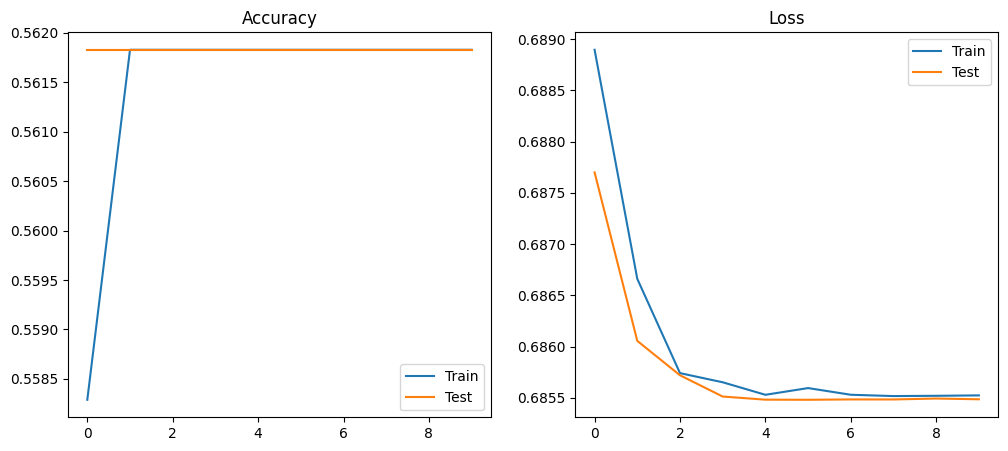

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Test'])

plt.show()

In [ ]:
model.save('/content/drive/MyDrive/efficientnetb0_sampah.h5')
print("Model berhasil disimpan!")

Model berhasil disimpan!
